In [1]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score, mean_squared_error

import numpy as np
import xarray as xr
g

import cartopy.crs as ccrs
import cartopy

import clustering_functions as cf
import preprocessing_functions as pf

#### Parameters

In [2]:
import pandas as pd

g0 = 9.80665
extended_winter_months = [11, 12, 1, 2, 3]

# CHANGE
cluster_number = 7
reconstruction_loss_factor = 0.5
filepath = "results/cmmvae/"

pr_cluster_number = 5

original_dim = 825
inputdim1 = 25
inputdim2 = 33

latent_dim = 15

activation_function = 'relu'

dim_layer1 = 256
dim_layer2 = 128
dim_layer3 = 64

cat_dim = 1

batch_size = 128
epochs = 150

input_shape = (original_dim, )
input_shape_r = (pr_cluster_number, )

### Data pre-processing

In [3]:
z500 = pf.preprocess_dataset(filename ='../../predictability_paper/data.nosync/era5_z500_daily_250_atlantic_1940_2022.nc',
                             variable_name = 'z',
                             multiplication_factor = 1/g0,
                             geographical_filter = 'new atlantic',
                             months_filter = extended_winter_months,
                             anomalies = True,
                             normalization = False,
                             rolling_window = 5)

z500 = z500.where(z500['time.year'] > 1980, drop=True)
z500 = z500.where(z500['time.year'] < 2023, drop=True)


weights = np.cos(np.deg2rad(z500.latitude))
z500 = z500*weights
z500 = z500/z500.std()

z500_reshaped = cf.reshape_data_for_clustering(z500)

In [4]:
# CHIRPS

pr_labels = pd.read_csv('../../predictability_paper/data.nosync/CHIRPS_pr_cluster_labels_5.csv')
pr_labels.columns = ['index', 'labels']
pr_labels.drop(pr_labels.tail(1).index,inplace=True)

pr_labels['values']=[1]*len(pr_labels)
label_indices_pd = pd.pivot_table(pr_labels, values='values', index=['index'],
                    columns=['labels'], aggfunc=np.sum).fillna(0)
label_indices = label_indices_pd.values

#threshold_qn95 = xr.open_dataset('../data.nosync/CHIRPS_pr_95pc_EW.nc')
#threshold_qn95 = threshold_qn95.where(threshold_qn95['time.year'] < 2023, drop=True)['precipitation_amount']

#pr_spatial = xr.open_dataset('../data.nosync/CHIRPS_pr_total_EW.nc')['precipitation_amount']
#pr_spatial = pr_spatial.where(pr_spatial['time.year'] < 2023, drop=True)

/var/folders/xm/7860nnpd3rzb5x0_d8d_nzhh0000gn/T/ipykernel_9331/3427147954.py:8: FutureWarning: The provided callable <function sum at 0x1061c2ef0> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  label_indices_pd = pd.pivot_table(pr_labels, values='values', index=['index'],


## Define model

In [5]:
import numpy as np

from cleaner_code_for_cmmvae.training import utils
from cleaner_code_for_cmmvae.training.vae import VAEBuilder, VAEConfig
from cleaner_code_for_cmmvae.training.loss import VAELoss
from cleaner_code_for_cmmvae.training.trainer import VAETrainer


filepath = "results/cmmvae/"
cluster_number = 7
original_dim = 825
pr_cluster_number = 5


vae_loss = VAELoss(reconstruction_loss_factor=0.5, original_dim=original_dim, pr_cluster_number=pr_cluster_number)

config = VAEConfig(
    original_dim=original_dim,
    original_dim_r=pr_cluster_number,
    dim_layer1=256,
    dim_layer2=128,
    dim_layer3=64,
    activation="relu",
    cluster_number=cluster_number,
    latent_dim=15,
    pr_cluster_number=pr_cluster_number,
    sampling_fn=utils.sampling,
)

vae = VAEBuilder(cfg=config, custom_loss=vae_loss).build()

vae.compile(optimizer='adam',metrics=None
)

vae.save_weights(filepath+'random_weights_'+str(cluster_number)+'.h5')


trainer = VAETrainer(
    model=vae,
    batch_size=batch_size,
)

history = trainer.fit(
    X=z500.values,
    y=label_indices,
    epochs=epochs,
    filepath=filepath+'random_weights_'+str(cluster_number)+'.h5',
)

Epoch 1/150
35/35 [==============================] - 1s 5ms/step - loss: 343.5177 - reconstruction: 315.6595 - kl_categorical: 0.1452 - dirichlet: 7.2556 - target: 4.5867 - kl_gaussian: 13.9641 - val_loss: 210.1355 - val_reconstruction: 178.2710 - val_kl_categorical: 0.0780 - val_dirichlet: 7.2096 - val_target: 5.0257 - val_kl_gaussian: 17.6594
Epoch 2/150
35/35 [==============================] - 0s 3ms/step - loss: 190.1036 - reconstruction: 156.7691 - kl_categorical: 0.0658 - dirichlet: 7.1716 - target: 3.9462 - kl_gaussian: 20.3526 - val_loss: 156.6997 - val_reconstruction: 124.2422 - val_kl_categorical: 0.0771 - val_dirichlet: 7.1375 - val_target: 4.5173 - val_kl_gaussian: 18.9687
Epoch 3/150
35/35 [==============================] - 0s 3ms/step - loss: 144.9533 - reconstruction: 110.1533 - kl_categorical: 0.0995 - dirichlet: 7.1092 - target: 3.7423 - kl_gaussian: 22.1229 - val_loss: 131.3913 - val_reconstruction: 98.4459 - val_kl_categorical: 0.0952 - val_dirichlet: 7.0830 - val_ta

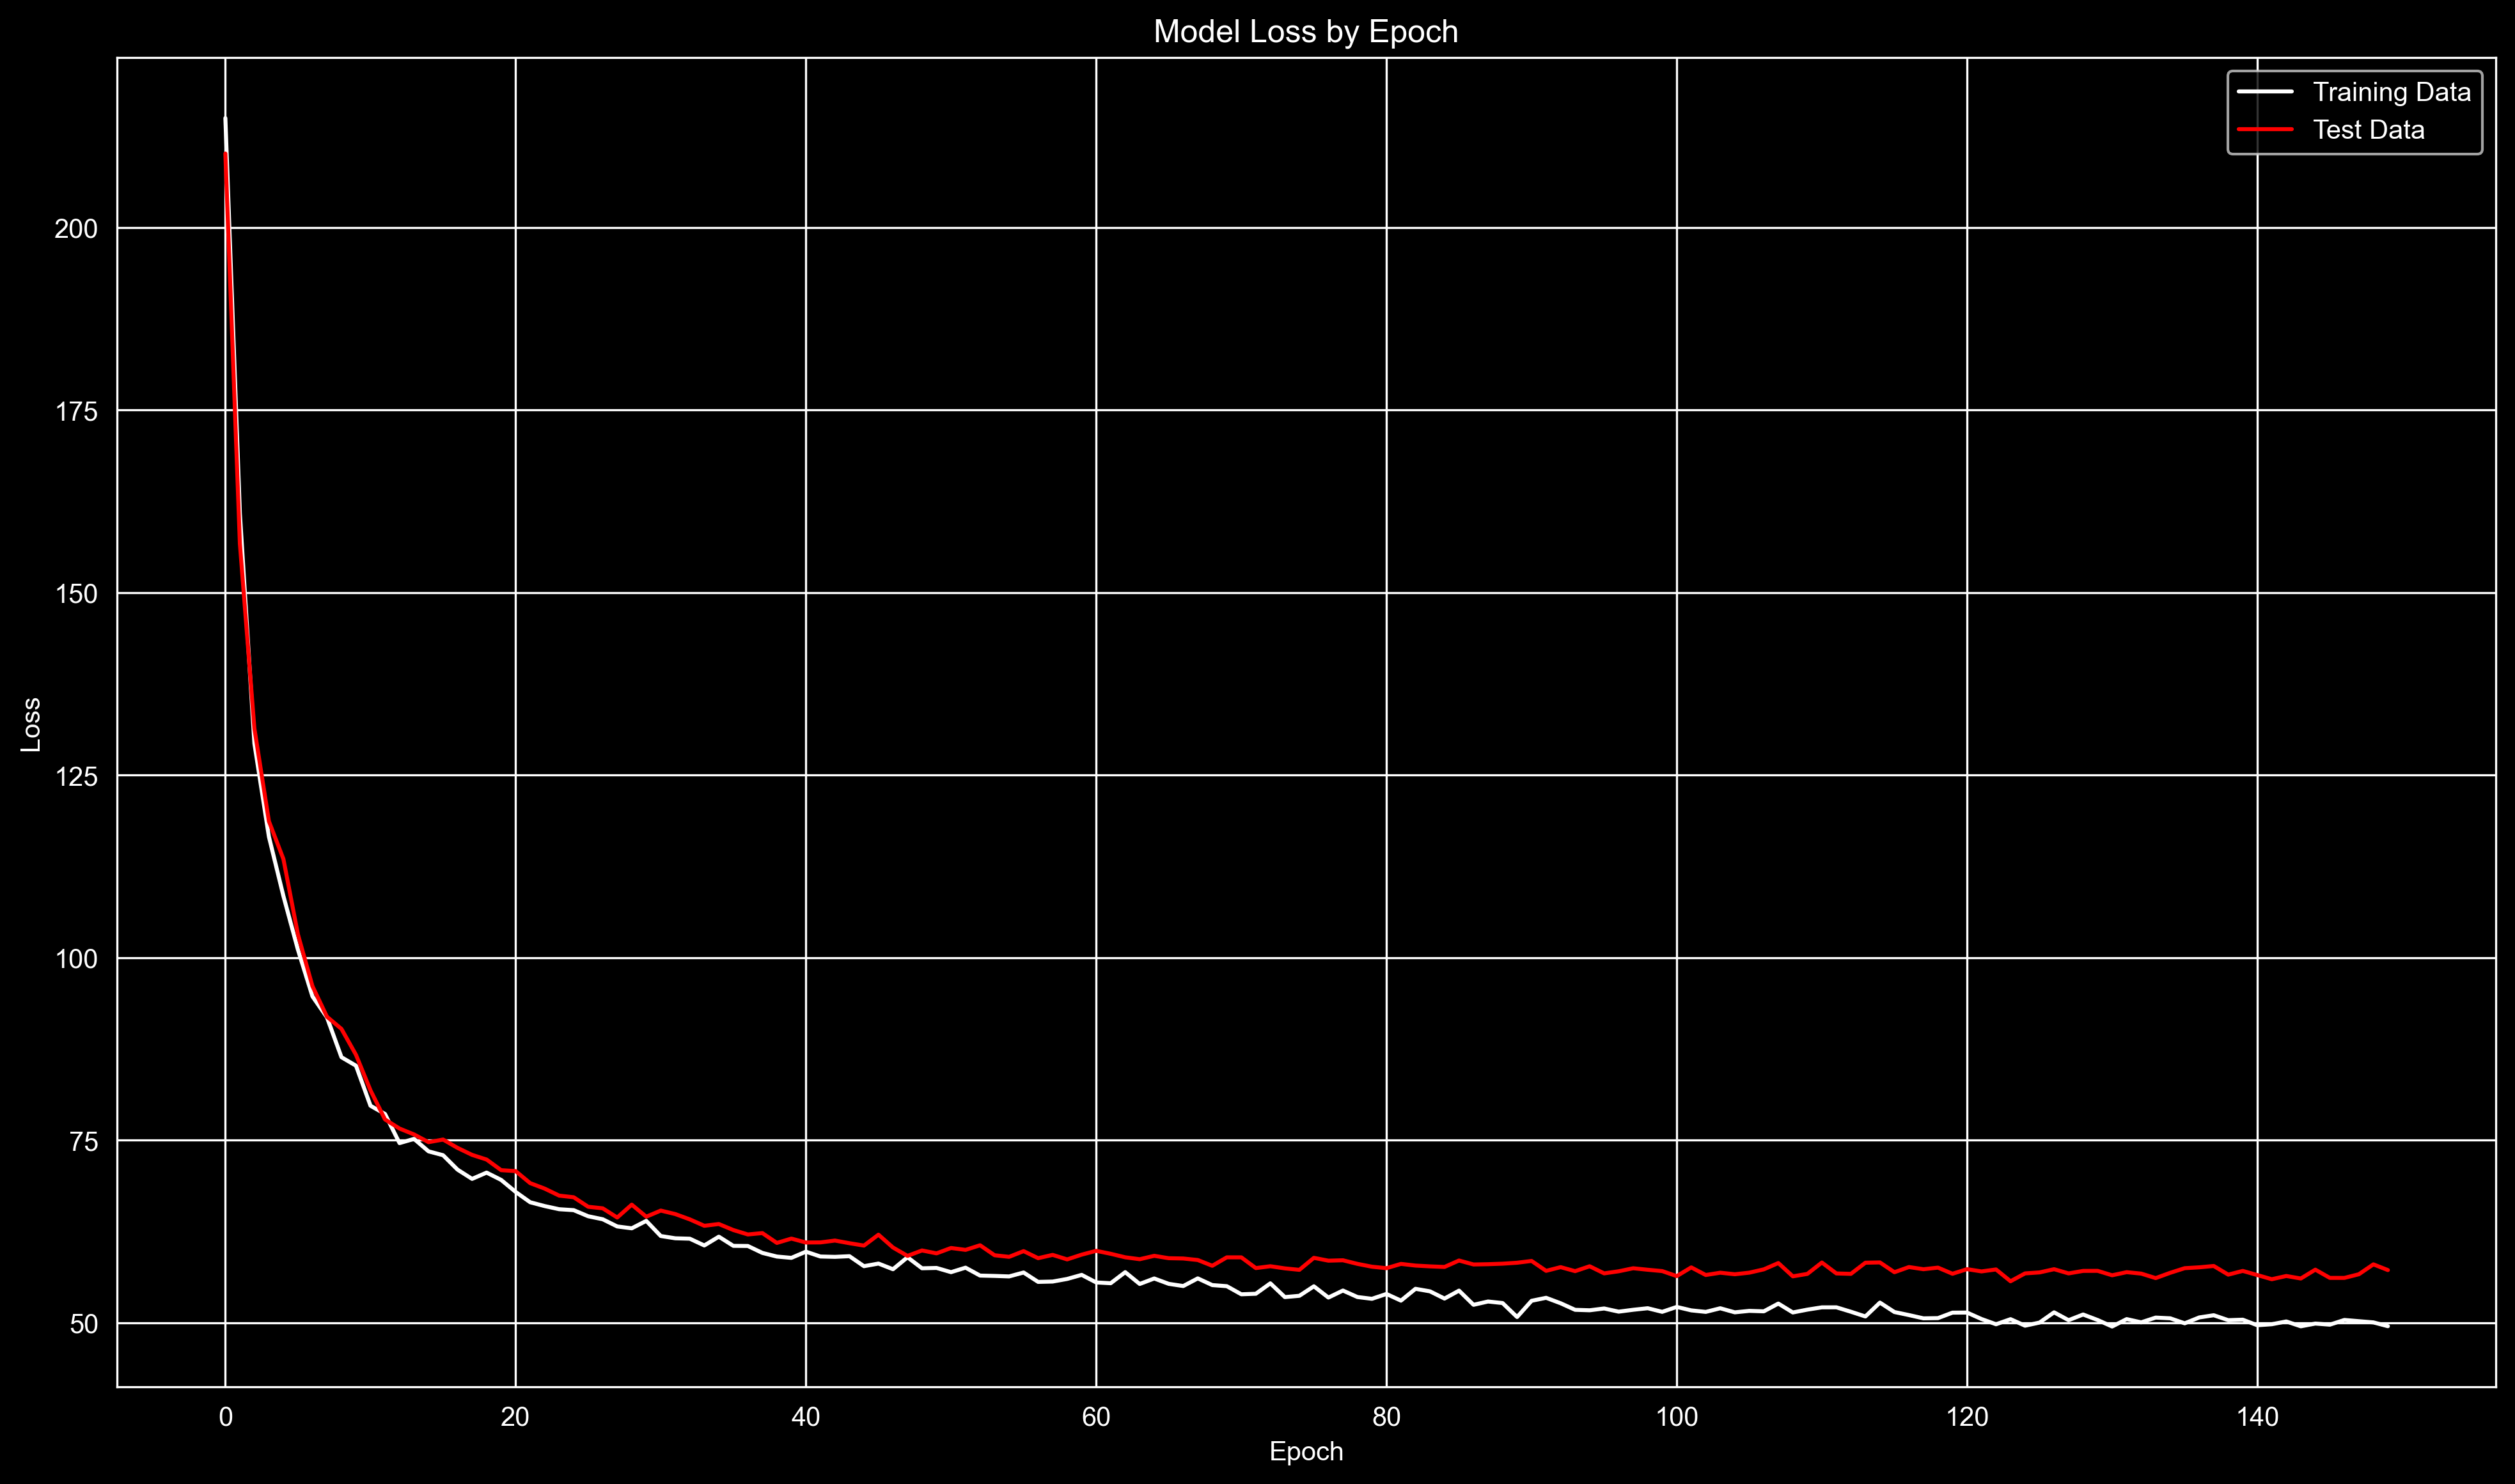

In [6]:
from cleaner_code_for_cmmvae.utils import plot_losses
import matplotlib.pyplot as plt

training_loss = history.history['loss']
validation_loss = history.history['val_loss']
plot_losses(training_loss, validation_loss)

In [7]:
from cleaner_code_for_cmmvae.training.crossValidator import CrossValidator


trainer = CrossValidator(
    trainer=trainer,
    filepath=filepath,
    cluster_number=cluster_number,
    n_runs=5,
)

histories = trainer.run(
    X=z500.values,
    y=label_indices,
    epochs=epochs,
)

Epoch 1/150
35/35 [==============================] - 0s 4ms/step - loss: 368.3145 - reconstruction: 344.1777 - kl_categorical: 0.1100 - dirichlet: 7.1191 - target: 4.6287 - kl_gaussian: 10.4843 - val_loss: 248.9232 - val_reconstruction: 210.3815 - val_kl_categorical: 0.0883 - val_dirichlet: 6.9845 - val_target: 4.5434 - val_kl_gaussian: 25.1961
Epoch 2/150
35/35 [==============================] - 0s 4ms/step - loss: 187.5934 - reconstruction: 152.7800 - kl_categorical: 0.1501 - dirichlet: 6.9336 - target: 4.1581 - kl_gaussian: 21.9093 - val_loss: 161.7436 - val_reconstruction: 128.3287 - val_kl_categorical: 0.1333 - val_dirichlet: 6.9035 - val_target: 3.4481 - val_kl_gaussian: 21.2769
Epoch 3/150
35/35 [==============================] - 0s 3ms/step - loss: 146.3629 - reconstruction: 112.0502 - kl_categorical: 0.2199 - dirichlet: 6.8940 - target: 3.9288 - kl_gaussian: 21.7176 - val_loss: 137.0809 - val_reconstruction: 103.3039 - val_kl_categorical: 0.2152 - val_dirichlet: 6.8893 - val_t

#### Cross-validation of model

**Load chosen weights and test on entire dataset**

In [8]:
chosen_count = 3
vae.load_weights(filepath+'final_weights_'+str(cluster_number)+'_'+str(chosen_count)+'.h5')

[z_mean_enc, z_log_var_enc, z_enc, mu_enc, c_enc, pi_enc, r_enc, cr_enc] = vae.predict([X,dummy_full, y],batch_size=batch_size)

NameError: name 'X' is not defined

## Evaluation

### Reconstruction loss and samples

In [ ]:
X_decoded = decoder.predict(z_enc)

reconstructed = X_decoded.reshape(X_decoded.shape[0], inputdim2, inputdim1)
reconstructed = np.transpose(reconstructed, (0, 2, 1))
reconstructed_xr = xr.DataArray(reconstructed, coords=z500[0:X_decoded.shape[0], :, :].coords, 
                         dims=z500[0:X_decoded.shape[0], :, :].dims, attrs=z500[0:X_decoded.shape[0], :, :].attrs)

mse_reconstruction = mean_squared_error(X_decoded, X, multioutput='raw_values')
d = {'MSE': 'VAE_CMM', 'k': cluster_number, 'Value': mse_reconstruction}
df = pd.DataFrame(data=d)

In [ ]:
for i in [5, 4660, 5930]:

    fig = plt.figure(figsize=[14,3])

    ax1 = fig.add_subplot(131, projection=ccrs.Orthographic(0,45))
    z500[i, :, :].plot(ax=ax1, cmap='RdBu_r', transform=ccrs.PlateCarree(), vmin=-2, vmax=2)
    ax1.coastlines()
    ax1.add_feature(cartopy.feature.BORDERS)

    ax2 = fig.add_subplot(132, projection = ccrs.Orthographic(0,45))
    reconstructed_xr[i, :, :].plot(ax=ax2, cmap='RdBu_r', transform=ccrs.PlateCarree(), vmin=-2, vmax=2)
    ax2.coastlines()
    ax2.add_feature(cartopy.feature.BORDERS)

## Skill score

In [ ]:
final_labels = np.zeros(X.shape[0])
for i in range(0, X.shape[0]):
    max_prob = np.max(c_enc[i,:])
    idx = np.argmax(c_enc[i,:])
    final_labels[i] = idx

In [ ]:
# get maximum likelihood labels

df = pd.DataFrame(data=c_enc)
df['label'] = final_labels
#df.to_csv(filepath+'cluster_probabilities_'+str(cluster_number)+'.csv')

print('calculating skill score')

bss_95 = sc.calculate_95pc_skill_score_probabilistic(cluster_number_z500 = cluster_number, 
                                                  z500_cluster_probabilities = c_enc, 
                                                  pr_spatial = pr_spatial)

print(bss_95)

bss_cluster = sc.calculate_cluster_skill_score_probabilistic(cluster_number_pr = 5, 
                                                             cluster_number_z500 = cluster_number, 
                                                             pr_cluster_labels = np.array(pr_labels['labels']),
                                                             z500_cluster_probabilities = c_enc)

print(bss_cluster)

bss_tercile = sc.calculate_tercile_skill_score_probabilistic(cluster_number_z500 = cluster_number, 
                                                  z500_cluster_probabilities = c_enc, 
                                                  pr_spatial = pr_spatial)

print(bss_tercile)

# FIRST ROUND
#df = pd.DataFrame(data={'k': [cluster_number], 'bss_cluster': [bss_cluster], 'bss_95': [bss_95], 'bss_tercile': [bss_tercile]})
#df.to_csv(filepath+'skill_score.csv', index=False)

# OTHER ROUND
df_prior = pd.read_csv(filepath+'skill_score.csv')
df = pd.DataFrame(data={'k': [cluster_number], 'bss_cluster': [bss_cluster], 'bss_95': [bss_95], 'bss_tercile': [bss_tercile]})
df_new = df_prior.append(df)
df_new.to_csv(filepath+'skill_score.csv', index=False)

### Cluster centers

In [ ]:
# re-order labels

precip_sum = pd.DataFrame(pr_spatial.values[:6352]).groupby(final_labels).sum().reset_index()
precip_sum['index']=precip_sum['index'].astype('int')
precip_sum = precip_sum.rename(columns={"index": "index_old"})
precip_sum = precip_sum.sort_values(by=0, ascending=False)
precip_sum['index_new'] = np.arange(precip_sum.shape[0])

labels_reordered = final_labels.copy()

for i in range(len(final_labels)):
    
    new_label = precip_sum[precip_sum['index_old']==final_labels[i].astype('int')]['index_new'].values[0]
    
    labels_reordered[i] = new_label
    
precip_sum['index_old'].values.tolist()

In [ ]:



# save re-ordered cluster labels and probabilities

df = pd.DataFrame(data=c_enc)
df_reordered = df[precip_sum['index_old'].values.tolist()]
df_reordered.columns= [*range(cluster_number)]
df_reordered['label'] = labels_reordered

#df_reordered.to_csv(filepath+'cluster_probabilities_'+str(cluster_number)+'_preciporder.csv')

df['label'] = final_labels
df.to_csv(filepath+'cluster_probabilities_'+str(cluster_number)+'.csv')



In [ ]:
# save cluster centers

z500_labels_preciporder = z500.assign_coords(label=("time", labels_reordered))/weights
z500_labels = z500.assign_coords(label=("time", final_labels))/weights

means_preciporder = z500_labels_preciporder.groupby('label').mean()
means = z500_labels.groupby('label').mean()

means_flat = cf.reshape_data_for_clustering(means)
means_flat_preciporder = cf.reshape_data_for_clustering(means_preciporder)

df1 = pd.DataFrame(data=means_flat)
df1.to_csv(filepath+'cluster_centers_'+str(cluster_number)+'.csv')

df2 = pd.DataFrame(data=means_flat_preciporder)
df2.to_csv(filepath+'cluster_centers_'+str(cluster_number)+'_preciporder.csv')

In [ ]:
cluster_centers_vis = cf.visualise_contourplot_labels_8(cluster_centers = means_preciporder, unit = '[m]', 
                                            regime_names = ['Regime 1', 'Regime 2', 'Regime 3',
                                                                         'Regime 4', 'Regime 5', 'Regime 6',
                                                                         'Regime 7', 'Regime 8', 'Regime 9', 'Regime 10'], 
                                             vmin=-4, vmax=4.5, steps=0.5, 
                                             color_scheme = 'RdBu_r', 
                                                      labels_data = X, labels=labels_reordered,
                                                      borders=False, 
                                                     col_number=cluster_number, projection = ccrs.AlbersEqualArea(central_longitude=-10, central_latitude=50))

plt.savefig(filepath+'cluster_centers_'+str(cluster_number)+'.png')

**Precipitation odds ratio**

In [ ]:
pr_qn95_ratio = cf.calculate_conditional_probability_change_label(threshold_matrix = threshold_qn95, 
                                                        labels=labels_reordered,
                                                       comparison = 'ratio', shift_value=0)

pr_qn95_vis = cf.visualise_spatial_oddsratio_8(dataset_xarray = pr_qn95_ratio, unit='', 
                                   color_scheme = 'GnBu', vmin = 0, vmax=5, steps=6, 
                                   title = 'Odds ratio of 95th percentile precipitation',
                                             regime_names = ['Regime 1', 'Regime 2', 'Regime 3',
                                                                         'Regime 4', 'Regime 5', 'Regime 6',
                                                                         'Regime 7', 'Regime 8', 'Regime 9', 'Regime 10'],
                                   borders=True, projection=ccrs.PlateCarree(central_longitude=0), 
                                               col_number=cluster_number)

plt.savefig(filepath+'precip_odds_ratio_'+str(cluster_number)+'_preciporder.png')


### Persistence & Silhouette

In [ ]:
persistence = cf.calculate_regime_length(labels_reordered.astype(int)).groupby('Regime').mean()['Length'].reset_index()

print(persistence['Length'].mean())

# FIRST ROUND
#df = pd.DataFrame(data={'k': [str(cluster_number)]*cluster_number,
#                        'Method': ['CMM-VAE']*cluster_number,
#                        'Regime': persistence['Regime'].values, 
#                        'Persistence': persistence['Length'].values})
#df.to_csv(filepath+'persistence.csv', index=False)


# OTHER ROUND
df_prior = pd.read_csv(filepath+'persistence.csv')
df = pd.DataFrame(data={'k': [str(cluster_number)]*cluster_number, 
                        'Method': ['CMM-VAE']*cluster_number,
                        'Regime': persistence['Regime'].values, 
                        'Persistence': persistence['Length'].values})
df_new = df_prior.append(df)
df_new.to_csv(filepath+'persistence.csv', index=False)

sil_score = silhouette_score(cf.reshape_data_for_clustering(z500), final_labels)
print(sil_score)

# FIRST ROUND
#df = pd.DataFrame(data={'k': [cluster_number], 'silhouette_score': [sil_score], 'method': ['CMM-VAE']})
#df.to_csv(filepath+'silhouette_score.csv', index=False)

# OTHER ROUND
df_prior = pd.read_csv(filepath+'silhouette_score.csv')
df = pd.DataFrame(data={'k': [cluster_number], 'silhouette_score': [sil_score], 'method': ['CMM-VAE']})
df_new = df_prior.append(df)
df_new.to_csv(filepath+'silhouette_score.csv', index=False)